In [8]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Literal , Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage
import os
import operator

### It will generate a Tweet on some topic than evaluate it. If tweet is good enough, it got approved and workflow ends but if not , than tweet will be sent to optimizer and optimizer make it good enough and send it back to evaluator. there will be loop between evaluator and Optimizer.

In [9]:
load_dotenv(override=True)
#we use gpt_4o as it gives better performance and reasoning capabilities,
#we use gpt_4o_mini as it gives structured output..

generator_llm_model = ChatOpenAI(
    model="gpt-4o", 
    api_key=os.getenv("github_OPENAI_KEY"), 
    base_url="https://models.inference.ai.azure.com" 
)
evaluator_llm_model = ChatOpenAI(
    model="gpt-4o-mini", 
    api_key=os.getenv("github_OPENAI_KEY"), 
    base_url="https://models.inference.ai.azure.com" 
)
optimizer_llm_model = ChatOpenAI(
    model="gpt-4o", 
    api_key=os.getenv("github_OPENAI_KEY"), 
    base_url="https://models.inference.ai.azure.com" 
)




try:
    print("Testing Updated GitHub Token...")
    print("Response:", optimizer_llm_model.invoke("Optimizer Hello!").content)
    print("Response:", generator_llm_model.invoke("Generator Hello!").content)
    print("Response:", evaluator_llm_model.invoke("Evaluator Hello!").content)
except Exception as e:
    print(f"Error: {e}")

Testing Updated GitHub Token...
Response: Hello there! 👋 How can I assist you today?
Response: Hello! How can I assist you today? 😊
Response: Hello! How can I assist you today?


In [10]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "rejected"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [11]:
structured_evaluator_llm_model = evaluator_llm_model.with_structured_output(TweetEvaluation)

In [12]:
#state of workflow
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation:Literal["approved", "rejected"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]
    

In [ ]:
def generate_tweet(state: TweetState) -> TweetState:
    prompt = [
                SystemMessage(content="You are a funny and clever Twitter/X influencer."),
                HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]
    
    response = generator_llm_model.invoke(prompt)
    response = response.content
    return {**state, "tweet": response , "tweet_history": state['tweet_history'] + [response]}


In [14]:

def evaluate_tweet(state: TweetState) -> TweetState:
    prompt = [
                SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
                HumanMessage(content=f"""
            Evaluate the following tweet:

            Tweet: "{state['tweet']}"

            Use the criteria below to evaluate the tweet:

            1. Originality – Is this fresh, or have you seen it a hundred times before?  
            2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
            3. Punchiness – Is it short, sharp, and scroll-stopping?  
            4. Virality Potential – Would people retweet or share it?  
            5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

            Auto-reject if:
            - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
            - It exceeds 280 characters
            - It reads like a traditional setup-punchline joke
            - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

            ### Respond ONLY in structured format:
            - evaluation: "approved" or "needs_improvement"  
            - feedback: One paragraph explaining the strengths and weaknesses 
            """)
            ]
    
    response = structured_evaluator_llm_model.invoke(prompt)
    
    return {**state, "evaluation": response.evaluation, "feedback": response.feedback , "feedback_history": state['feedback_history'] + [response.feedback]}

In [15]:
def optimize_tweet(state: TweetState):

    prompt = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm_model.invoke(prompt)
    iteration = state['iteration'] + 1

    return {**state, 'tweet': response, 'iteration': iteration, 'tweet_history': state['tweet_history'] + [response]}

In [16]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'rejected'

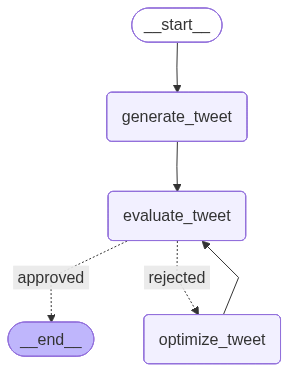

In [17]:
#creating graph

graph = StateGraph(TweetState)

#defining nodes 
graph.add_node("generate_tweet", generate_tweet)
graph.add_node("evaluate_tweet", evaluate_tweet)
graph.add_node("optimize_tweet", optimize_tweet)


#edges
graph.add_edge(START, "generate_tweet")
graph.add_edge("generate_tweet", "evaluate_tweet")
graph.add_conditional_edges("evaluate_tweet", route_evaluation, {"approved": END, "rejected": "optimize_tweet"})
graph.add_edge("optimize_tweet", "evaluate_tweet")

#execute graph
workflow = graph.compile()
workflow


In [20]:
initial_state = {
    "topic": "AI in society",
    "iteration": 1,
    "max_iteration": 3 
}

workflow.invoke(initial_state)

c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TweetEvaluation(evaluatio...appreciated for humor."), input_type=TweetEvaluation])
  return self.__pydantic_serializer__.to_python(
c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TweetEvaluation(evaluatio...and pizza preferences.'), input_type=TweetEvaluation])
  return self.__pydantic_serializer__.to_python(


{'topic': 'AI in society',
 'tweet': AIMessage(content='"AI is like pineapple on pizza: some people love it, some hate it, and most are just confused it’s here at all. Except the pineapple learns your preferences, automates your job, and maybe takes over society. Anyway, vibes."', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 812, 'total_tokens': 863, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_af7f7349a4', 'id': 'chatcmpl-DHcZ3VX9oU2iyof1jzL0wkLZhsw8B', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd487-b3d4-7502-96d0-c6cfaa1046ac-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 812, 'output_tokens': 51, 'total_tokens': 863, 'input_t